# Basic Monthly Regime-Switching Backtest

This notebook implements the first realistic walk-forward portfolio strategy in the project. The goal is to evaluate whether a **regime-aware allocation process** improves portfolio performance relative to standard benchmark strategies when portfolio decisions are made sequentially through time.

Unlike the previous notebooks, which focused primarily on **historical regime discovery** and **in-sample regime-specific portfolio construction**, this notebook moves to a true **walk-forward backtesting framework**.

At each month-end, the strategy:

1. uses only information available up to that date,
2. re-estimates the HMM using the expanding historical sample,
3. identifies the current market regime,
4. estimates portfolio inputs from the expanding training window,
5. computes portfolio weights,
6. and holds those weights over the next month.

This notebook compares three strategies:

- **Equal Weight**
- **Static Expanding-Window Mean-Variance**
- **Regime-Aware Hard-Switch Strategy**

The regime-aware strategy in this notebook is still **reactive rather than predictive**. It uses the **current regime detected at month-end** rather than forecasted future regime probabilities. Forecast-based allocation will be introduced in later notebooks.

## Strategy Overview

This notebook evaluates three monthly rebalanced portfolio strategies.

### 1. Equal Weight
A simple benchmark that allocates equally across all assets each month.

### 2. Static Expanding-Window Mean-Variance
A traditional mean-variance benchmark that ignores market regimes. At each month-end, it estimates a single expanding-window mean vector and covariance matrix using all historical daily returns available up to that date, then computes the long-only maximum Sharpe portfolio.

### 3. Regime-Aware Hard-Switch Strategy
At each month-end, this strategy re-fits a Hidden Markov Model using only the historical feature data available up to that date. It then identifies the current regime on the last trading day of the month, estimates regime-specific mean returns and covariance matrices from the labeled training sample, and allocates to the portfolio corresponding to the current regime.

### Monthly decision rule

At the end of month $t$:

- observe all data through month-end $t$,
- estimate model inputs using an expanding historical sample,
- determine portfolio weights,
- and hold the selected portfolio during month $t+1$.

This structure avoids lookahead bias and mimics a realistic investment process.

## Optimization Method Change

In earlier notebooks, portfolio optimization was implemented using **Monte Carlo simulation**. That approach was appropriate for the earlier stage of the project because it helped:

- visualize the feasible set of portfolios,
- approximate efficient frontiers,
- build intuition about how allocations differ across regimes,
- and support exploratory analysis.

In this notebook, however, the objective shifts from **descriptive frontier analysis** to **repeated walk-forward portfolio implementation**.

Because portfolio weights must now be recomputed at each monthly rebalance date using updated estimates of expected returns and covariance matrices, **constrained numerical optimization** is more appropriate than Monte Carlo simulation. Constrained optimization provides:

- deterministic portfolio solutions,
- no simulation noise,
- faster repeated computation,
- and a cleaner framework for realistic backtesting.

In this notebook, portfolio weights are computed by solving standard **mean–variance optimization problems** under long-only constraints.

### Minimum Variance Portfolio

The minimum variance portfolio solves:

$$
\min_{w} \quad w^\top \Sigma w
$$

subject to:

$$
\sum_{i=1}^{N} w_i = 1
\qquad\text{and}\qquad
0 \le w_i \le 1
$$

where:

- $w$ is the vector of portfolio weights,
- $\Sigma$ is the asset return covariance matrix,
- $N$ is the number of assets.

### Maximum Sharpe Ratio Portfolio

The maximum Sharpe portfolio solves:

$$
\max_{w} \quad \frac{w^\top \mu - r_f}{\sqrt{w^\top \Sigma w}}
$$

subject to:

$$
\sum_{i=1}^{N} w_i = 1
\qquad\text{and}\qquad
0 \le w_i \le 1
$$

where:

- $\mu$ is the vector of expected returns,
- $\Sigma$ is the covariance matrix of returns,
- $r_f$ is the risk-free rate.

These optimization problems are solved numerically using constrained optimization routines, allowing the portfolio to be recomputed efficiently at each monthly rebalance date during the walk-forward backtest.

In [4]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import minimize
from hmmlearn.hmm import GaussianHMM

# Paths
project_root = Path("..")
data_dir = project_root / "data" / "processed"
results_dir = project_root / "results" / "notebook_06_backtest"
results_dir.mkdir(parents=True, exist_ok=True)

# Plot settings
plt.style.use("default")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

# Display settings
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)

In [ ]:
# Load daily asset returns
returns = pd.read_csv(
    data_dir / "asset_returns.csv",
    index_col=0,
    parse_dates=True
)

assets = ["SPY", "EFA", "GLD", "TLT", "VNQ"]
returns = returns[assets].copy().sort_index()

print("Returns shape:", returns.shape)
print("Assets:", assets)

Returns shape: (4068, 5)
Assets: ['SPY', 'EFA', 'GLD', 'TLT', 'VNQ']
                 SPY       EFA       GLD       TLT       VNQ
Date                                                        
2010-01-05  0.002644  0.000881 -0.000911  0.006438 -0.001123
2010-01-06  0.000704  0.004218  0.016365 -0.013477 -0.001800
2010-01-07  0.004212 -0.003866 -0.006207  0.001680  0.010749
2010-01-08  0.003322  0.007891  0.004951 -0.000447 -0.007377
2010-01-11  0.001396  0.008176  0.013201 -0.005503  0.005817


In [6]:
# Rebuild HMM feature inputs
hmm_features = pd.DataFrame(index=returns.index)
hmm_features["SPY_return"] = returns["SPY"]
hmm_features["SPY_volatility_20d"] = returns["SPY"].rolling(window=20).std()

# Drop rows lost to rolling window construction
hmm_features = hmm_features.dropna().copy()

print("HMM feature shape:", hmm_features.shape)

HMM feature shape: (4049, 2)


Inspect loaded data and created features

In [8]:
print("Daily returns date range:")
print(f"  Start: {returns.index.min().date()}")
print(f"  End:   {returns.index.max().date()}")
print()

print("HMM feature date range:")
print(f"  Start: {hmm_features.index.min().date()}")
print(f"  End:   {hmm_features.index.max().date()}")
print()

print("Returns head:")
display(returns.head())

print("Returns tail:")
display(returns.tail())

print("HMM features head:")
display(hmm_features.head())

print("HMM features tail:")
display(hmm_features.tail())

print("Missing values in returns:")
display(returns.isna().sum())

print("Missing values in HMM features:")
display(hmm_features.isna().sum())

Daily returns date range:
  Start: 2010-01-05
  End:   2026-03-09

HMM feature date range:
  Start: 2010-02-02
  End:   2026-03-09

Returns head:


,SPY,EFA,GLD,TLT,VNQ
Date,,,,,
2010-01-05,0.002644,0.000881,-0.000911,0.006438,-0.001123
2010-01-06,0.000704,0.004218,0.016365,-0.013477,-0.001800
2010-01-07,0.004212,-0.003866,-0.006207,0.001680,0.010749
2010-01-08,0.003322,0.007891,0.004951,-0.000447,-0.007377
2010-01-11,0.001396,0.008176,0.013201,-0.005503,0.005817


Returns tail:


,SPY,EFA,GLD,TLT,VNQ
Date,,,,,
2026-03-03,-0.008853,-0.031568,-0.045638,-0.002011,-0.005331
2026-03-04,0.007031,0.012806,0.007788,-0.003136,0.001257
2026-03-05,-0.005591,-0.022141,-0.012091,-0.004046,-0.010099
2026-03-06,-0.013194,-0.008914,0.015708,-0.003724,-0.010950
2026-03-09,0.008722,0.007198,-0.002072,0.008667,0.002242


HMM features head:


...

,SPY_return,SPY_volatility_20d
Date,,
2026-03-03,-0.008853,0.008309
2026-03-04,0.007031,0.008307
2026-03-05,-0.005591,0.008330
2026-03-06,-0.013194,0.008379
2026-03-09,0.008722,0.007383


Missing values in returns:


SPY    0
EFA    0
GLD    0
TLT    0
VNQ    0
dtype: int64

Missing values in HMM features:


SPY_return            0
SPY_volatility_20d    0
dtype: int64

## Daily Estimation and Monthly Portfolio Decisions

Although the Hidden Markov Model and covariance estimation procedures use **daily data**, portfolio decisions in this notebook are made **once per month**.

This hybrid structure is intentional:

- Daily data provides a richer sample for estimating volatility and covariance structure.
- Monthly rebalancing is more realistic for portfolio implementation and reduces excessive turnover.

The timing structure of the strategy is:

1. At the **last trading day of month $t$**:
   - observe all daily data up to that date
   - estimate model inputs using an expanding historical sample

2. Compute portfolio weights.

3. Hold those weights during **month $t+1$**.

This structure ensures that the backtest avoids **look-ahead bias**, since allocations are always based only on information available at the decision date.

In [10]:
# Convert daily log returns to monthly simple returns
monthly_log_returns = returns.resample("ME").sum()

monthly_returns = np.exp(monthly_log_returns) - 1
monthly_returns = monthly_returns.dropna()

print("Monthly returns shape:", monthly_returns.shape)

display(monthly_returns.head())
display(monthly_returns.tail())

Monthly returns shape: (195, 5)


,SPY,EFA,GLD,TLT,VNQ
Date,,,,,
2010-01-31,-0.052413,-0.074917,-0.034973,0.027837,-0.051179
2010-02-28,0.031194,0.002668,0.032748,-0.003424,0.055831
2010-03-31,0.060880,0.063854,-0.004386,-0.020574,0.101868
2010-04-30,0.015470,-0.028046,0.058834,0.033218,0.071502
2010-05-31,-0.079455,-0.111928,0.030513,0.051085,-0.053346


,SPY,EFA,GLD,TLT,VNQ
Date,,,,,
2025-11-30,0.001950,0.007408,0.053678,0.002723,0.024221
2025-12-31,0.000797,0.027105,0.021734,-0.026586,-0.022363
2026-01-31,0.014738,0.049047,0.122732,-0.000344,0.026105
2026-02-28,-0.008642,0.046059,0.087201,0.042351,0.053855
2026-03-31,-0.011254,-0.060638,-0.023194,-0.014240,-0.020169


In [11]:
# Identify last trading day of each month
month_end_dates = returns.resample("ME").apply(lambda x: x.index[-1])

month_end_dates = month_end_dates.iloc[:, 0]
month_end_dates.name = "decision_date"

month_end_df = pd.DataFrame({
    "month_label": month_end_dates.index,
    "decision_date": month_end_dates.values
})

display(month_end_df.head())
display(month_end_df.tail())

,month_label,decision_date
0,2010-01-31,2010-01-29
1,2010-02-28,2010-02-26
2,2010-03-31,2010-03-31
3,2010-04-30,2010-04-30
4,2010-05-31,2010-05-28


,month_label,decision_date
190,2025-11-30,2025-11-28
191,2025-12-31,2025-12-31
192,2026-01-31,2026-01-30
193,2026-02-28,2026-02-27
194,2026-03-31,2026-03-09


In [13]:
# Backtest structure
backtest_df = pd.DataFrame(index=monthly_returns.index)

# Next-month realized returns
forward_returns = monthly_returns.shift(-1)

display(backtest_df.head())
display(forward_returns.head())

""
Date
2010-01-31
2010-02-28
2010-03-31
2010-04-30
2010-05-31


,SPY,EFA,GLD,TLT,VNQ
Date,,,,,
2010-01-31,0.031194,0.002668,0.032748,-0.003424,0.055831
2010-02-28,0.060880,0.063854,-0.004386,-0.020574,0.101868
2010-03-31,0.015470,-0.028046,0.058834,0.033218,0.071502
2010-04-30,-0.079455,-0.111928,0.030513,0.051085,-0.053346
2010-05-31,-0.051741,-0.020619,0.023553,0.057978,-0.052123


In [ ]:
# Reset decision_schedule to only the schedule columns
decision_schedule = month_end_df.copy()

# The month whose returns will be earned after the decision date
decision_schedule["holding_month"] = decision_schedule["month_label"].shift(-1)

# Drop the final row because there is no next-month holding period
decision_schedule = decision_schedule.dropna().copy()

# Keep only the schedule fields before merging returns
decision_schedule = decision_schedule[["month_label", "decision_date", "holding_month"]].copy()

display(decision_schedule.head())

,month_label,decision_date,holding_month
0,2010-01-31,2010-01-29,2010-02-28
1,2010-02-28,2010-02-26,2010-03-31
2,2010-03-31,2010-03-31,2010-04-30
3,2010-04-30,2010-04-30,2010-05-31
4,2010-05-31,2010-05-28,2010-06-30


In [ ]:
# Attach next-month realized returns
decision_schedule = decision_schedule.merge(
    forward_returns,
    left_on="month_label",
    right_index=True,
    how="left"
)

display(decision_schedule.head())

,month_label,decision_date,holding_month,SPY,EFA,GLD,TLT,VNQ
0,2010-01-31,2010-01-29,2010-02-28,0.031194,0.002668,0.032748,-0.003424,0.055831
1,2010-02-28,2010-02-26,2010-03-31,0.060880,0.063854,-0.004386,-0.020574,0.101868
2,2010-03-31,2010-03-31,2010-04-30,0.015470,-0.028046,0.058834,0.033218,0.071502
3,2010-04-30,2010-04-30,2010-05-31,-0.079455,-0.111928,0.030513,0.051085,-0.053346
4,2010-05-31,2010-05-28,2010-06-30,-0.051741,-0.020619,0.023553,0.057978,-0.052123


In [23]:
# Rename forward return columns
forward_return_cols = {asset: f"{asset}_forward_return" for asset in assets}
decision_schedule = decision_schedule.rename(columns=forward_return_cols)

print(decision_schedule.head())

  month_label decision_date holding_month  SPY_forward_return  EFA_forward_return  GLD_forward_return  TLT_forward_return  \
0  2010-01-31    2010-01-29    2010-02-28            0.031194            0.002668            0.032748           -0.003424   
1  2010-02-28    2010-02-26    2010-03-31            0.060880            0.063854           -0.004386           -0.020574   
2  2010-03-31    2010-03-31    2010-04-30            0.015470           -0.028046            0.058834            0.033218   
3  2010-04-30    2010-04-30    2010-05-31           -0.079455           -0.111928            0.030513            0.051085   
4  2010-05-31    2010-05-28    2010-06-30           -0.051741           -0.020619            0.023553            0.057978   

   VNQ_forward_return  
0            0.055831  
1            0.101868  
2            0.071502  
3           -0.053346  
4           -0.052123  


## Backtest Decision Table

The table above defines the **timeline used for the walk-forward backtest**. Each row represents a single portfolio decision and the realized asset returns that occur after that decision.

The columns have the following interpretation:

- **month_label**  
  The calendar month-end label corresponding to the decision period.

- **decision_date**  
  The actual **last trading day of the month**, when the portfolio allocation decision is made.  
  At this point the strategy observes all historical data available up to this date.

- **holding_month**  
  The month during which the selected portfolio will be held.

- **\_forward_return columns**  
  These contain the **realized asset returns during the following month**, which are used to evaluate the performance of the portfolio selected at the decision date.

### Example

Consider the first row:

| month_label | decision_date | holding_month |
|-------------|---------------|---------------|
| 2010-01-31  | 2010-01-29    | 2010-02-28    |

This means:

1. On **January 29, 2010** (the last trading day of January), the strategy computes portfolio weights using all historical data available up to that date.
2. The portfolio is then **held throughout February 2010**.
3. The portfolio’s realized return is computed using the **February asset returns** shown in the forward return columns.

### Why this structure is necessary

This design ensures the backtest avoids **look-ahead bias**. Portfolio allocations are always based only on information available at the decision date, while performance is measured using **future returns that occur after the decision**.

In the walk-forward backtest that follows, each row of this table will correspond to one portfolio rebalance. The strategy will:

1. Use historical data up to the **decision_date** to estimate model inputs.
2. Compute portfolio weights.
3. Apply those weights to the **forward returns during the holding month**.
4. Record the resulting portfolio return.

## Minimum Training Window

Before the strategy begins trading, the model must observe a sufficient amount of historical data in order to produce stable parameter estimates.

Several components of the system rely on historical observations:

- estimation of covariance matrices
- estimation of expected returns
- fitting the Hidden Markov Model used for regime detection

If the strategy began trading immediately at the start of the dataset, these estimates would be extremely unstable due to the limited sample size.

To address this, the backtest imposes a **minimum training window**. Portfolio decisions are only allowed once the dataset contains at least a specified number of historical daily observations.

In this implementation we require **750 trading days of historical data** (approximately three years) before the first portfolio rebalance occurs. This provides enough observations for reasonably stable covariance and regime estimates.

The backtest will therefore begin only after this minimum history requirement is satisfied.

In [25]:
# Minimum training window

min_training_days = 750

valid_decision_dates = []

for date in decision_schedule["decision_date"]:

    history = returns.loc[:date]

    if len(history) >= min_training_days:
        valid_decision_dates.append(date)

valid_decision_dates = pd.to_datetime(valid_decision_dates)

print("First valid decision date:", valid_decision_dates[0].date())
print("Number of rebalance periods:", len(valid_decision_dates))

First valid decision date: 2012-12-31
Number of rebalance periods: 159


In [26]:
# Keep only valid rebalance periods

decision_schedule = decision_schedule[
    decision_schedule["decision_date"].isin(valid_decision_dates)
].copy()

decision_schedule = decision_schedule.reset_index(drop=True)

display(decision_schedule.head())
display(decision_schedule.tail())

,month_label,decision_date,holding_month,SPY_forward_return,EFA_forward_return,GLD_forward_return,TLT_forward_return,VNQ_forward_return
0,2012-12-31,2012-12-31,2013-01-31,0.051190,0.037284,-0.005061,-0.031853,0.037386
1,2013-01-31,2013-01-31,2013-02-28,0.012759,-0.012885,-0.050868,0.012387,0.012159
2,2013-02-28,2013-02-28,2013-03-31,0.037971,0.013054,0.009477,-0.004195,0.028722
3,2013-03-31,2013-03-28,2013-04-30,0.019212,0.050187,-0.075623,0.046849,0.067347
4,2013-04-30,2013-04-30,2013-05-31,0.023610,-0.030191,-0.061988,-0.067610,-0.059777


,month_label,decision_date,holding_month,SPY_forward_return,EFA_forward_return,GLD_forward_return,TLT_forward_return,VNQ_forward_return
154,2025-10-31,2025-10-31,2025-11-30,0.001950,0.007408,0.053678,0.002723,0.024221
155,2025-11-30,2025-11-28,2025-12-31,0.000797,0.027105,0.021734,-0.026586,-0.022363
156,2025-12-31,2025-12-31,2026-01-31,0.014738,0.049047,0.122732,-0.000344,0.026105
157,2026-01-31,2026-01-30,2026-02-28,-0.008642,0.046059,0.087201,0.042351,0.053855
158,2026-02-28,2026-02-27,2026-03-31,-0.011254,-0.060638,-0.023194,-0.014240,-0.020169


---
## Portfolio Math and Optimization Functions

With the walk-forward decision schedule now established, the next step is to define the core portfolio construction functions that will be used repeatedly throughout the backtest.

These functions serve three main purposes:

1. **Portfolio evaluation**  
   Compute portfolio return, volatility, and risk-adjusted performance from a set of weights and estimated moments.

2. **Performance measurement**  
   Compute quantities such as cumulative returns, annualized return, annualized volatility, Sharpe ratio, and drawdowns once the backtest is complete.

3. **Portfolio optimization**  
   Solve for the long-only fully invested portfolio that minimizes variance or maximizes the Sharpe ratio at each monthly rebalance date.

These functions will later be called inside the walk-forward loop for each strategy.

In [27]:
# Portfolio math helpers

def portfolio_return(weights, expected_returns):
    """
    Compute expected portfolio return from weights and expected asset returns.
    """
    weights = np.asarray(weights)
    expected_returns = np.asarray(expected_returns)
    return weights @ expected_returns


def portfolio_volatility(weights, covariance_matrix):
    """
    Compute portfolio volatility from weights and covariance matrix.
    """
    weights = np.asarray(weights)
    covariance_matrix = np.asarray(covariance_matrix)
    return np.sqrt(weights @ covariance_matrix @ weights)


def portfolio_sharpe_ratio(weights, expected_returns, covariance_matrix, rf=0.0):
    """
    Compute portfolio Sharpe ratio.
    """
    port_return = portfolio_return(weights, expected_returns)
    port_vol = portfolio_volatility(weights, covariance_matrix)

    if port_vol == 0:
        return np.nan

    return (port_return - rf) / port_vol

In [28]:
# Backtest performance helpers

def cumulative_growth(return_series, initial_value=1.0):
    """
    Convert a return series into a cumulative wealth index.
    """
    return initial_value * (1 + return_series).cumprod()


def annualized_return(return_series, periods_per_year=12):
    """
    Compute annualized return from a periodic return series.
    """
    n_periods = len(return_series)
    if n_periods == 0:
        return np.nan

    total_growth = (1 + return_series).prod()
    return total_growth ** (periods_per_year / n_periods) - 1


def annualized_volatility(return_series, periods_per_year=12):
    """
    Compute annualized volatility from a periodic return series.
    """
    return return_series.std(ddof=1) * np.sqrt(periods_per_year)


def annualized_sharpe_ratio(return_series, rf=0.0, periods_per_year=12):
    """
    Compute annualized Sharpe ratio from a periodic return series.
    Assumes rf is expressed at the same periodicity as the returns unless adjusted beforehand.
    """
    vol = annualized_volatility(return_series, periods_per_year=periods_per_year)
    if vol == 0:
        return np.nan

    ann_ret = annualized_return(return_series, periods_per_year=periods_per_year)
    ann_rf = (1 + rf) ** periods_per_year - 1 if rf != 0 else 0.0

    return (ann_ret - ann_rf) / vol


def drawdown_series(return_series):
    """
    Compute drawdown series from periodic returns.
    """
    wealth = cumulative_growth(return_series, initial_value=1.0)
    running_max = wealth.cummax()
    return wealth / running_max - 1


def max_drawdown(return_series):
    """
    Compute maximum drawdown from periodic returns.
    """
    dd = drawdown_series(return_series)
    return dd.min()


def portfolio_turnover(new_weights, old_weights):
    """
    Compute one-period portfolio turnover as the sum of absolute weight changes.
    """
    new_weights = np.asarray(new_weights)
    old_weights = np.asarray(old_weights)
    return np.abs(new_weights - old_weights).sum()

In [29]:
# Optimization objective functions

def variance_objective(weights, covariance_matrix):
    """
    Objective function for minimum variance optimization.
    """
    return portfolio_volatility(weights, covariance_matrix) ** 2


def negative_sharpe_objective(weights, expected_returns, covariance_matrix, rf=0.0):
    """
    Objective function for maximum Sharpe optimization.
    Since scipy minimizes, we minimize the negative Sharpe ratio.
    """
    sharpe = portfolio_sharpe_ratio(weights, expected_returns, covariance_matrix, rf=rf)

    if np.isnan(sharpe):
        return 1e6

    return -sharpe

In [30]:
# Constrained optimization wrappers

def optimize_min_variance(expected_returns, covariance_matrix, weight_bounds=(0.0, 1.0)):
    """
    Solve for the long-only fully invested minimum variance portfolio.
    """
    n_assets = len(expected_returns)

    initial_weights = np.repeat(1 / n_assets, n_assets)
    bounds = [weight_bounds] * n_assets
    constraints = [{"type": "eq", "fun": lambda w: np.sum(w) - 1}]

    result = minimize(
        fun=variance_objective,
        x0=initial_weights,
        args=(covariance_matrix,),
        method="SLSQP",
        bounds=bounds,
        constraints=constraints
    )

    return {
        "weights": result.x,
        "success": result.success,
        "message": result.message,
        "fun": result.fun
    }


def optimize_max_sharpe(expected_returns, covariance_matrix, rf=0.0, weight_bounds=(0.0, 1.0)):
    """
    Solve for the long-only fully invested maximum Sharpe ratio portfolio.
    """
    n_assets = len(expected_returns)

    initial_weights = np.repeat(1 / n_assets, n_assets)
    bounds = [weight_bounds] * n_assets
    constraints = [{"type": "eq", "fun": lambda w: np.sum(w) - 1}]

    result = minimize(
        fun=negative_sharpe_objective,
        x0=initial_weights,
        args=(expected_returns, covariance_matrix, rf),
        method="SLSQP",
        bounds=bounds,
        constraints=constraints
    )

    return {
        "weights": result.x,
        "success": result.success,
        "message": result.message,
        "fun": result.fun
    }

Quick optimizer sanity check

In [ ]:
sample_returns = returns.loc[:decision_schedule.loc[0, "decision_date"], assets]

sample_mu = sample_returns.mean().values * 252
sample_cov = sample_returns.cov().values * 252

min_var_test = optimize_min_variance(sample_mu, sample_cov)
max_sharpe_test = optimize_max_sharpe(sample_mu, sample_cov, rf=0.0)

print("Min-variance optimization success:", min_var_test["success"])
print("Max-Sharpe optimization success:", max_sharpe_test["success"])
print()

print("Min-variance weights sum:", min_var_test["weights"].sum())
print("Max-Sharpe weights sum:", max_sharpe_test["weights"].sum())
print()

print("Min-variance weights:")
print(pd.Series(min_var_test["weights"], index=assets).round(4))
print()

print("Max-Sharpe weights:")
print(pd.Series(max_sharpe_test["weights"], index=assets).round(4))

Min-variance optimization success: True
Max-Sharpe optimization success: True

Min-variance weights sum: 1.0
Max-Sharpe weights sum: 1.0000000000000007

Min-variance weights:
SPY    0.4284
EFA    0.0000
GLD    0.0970
TLT    0.4746
VNQ    0.0000
dtype: float64

Max-Sharpe weights:
SPY    0.2943
EFA    0.0000
GLD    0.1250
TLT    0.4803
VNQ    0.1003
dtype: float64


### Optimizer Validation

Using historical returns available at the first valid rebalance date, the code estimated a sample mean return vector and covariance matrix and then solved for the corresponding:

- **minimum variance portfolio**, and  
- **maximum Sharpe ratio portfolio**.

The purpose of this step was not to generate backtest results, but rather to verify that the constrained optimizer behaves as expected. In particular, the output confirms that:

- the optimization routine successfully converges,
- portfolio weights satisfy the long-only constraints $0 \le w_i \le 1$,
- the weights sum to one, ensuring the portfolio is fully invested, and
- the resulting allocations appear economically reasonable.

This validation step ensures that the optimization routines are reliable before they are used repeatedly within the walk-forward backtest.

### Transition to Walk-Forward Estimation

Although the optimizer can compute portfolio weights once the expected returns and covariance matrix are provided, those quantities must still be **estimated from historical data at each rebalance date**.

In a realistic trading strategy, these parameters are not known in advance and must be recomputed using only information available up to the current decision date. As a result, the backtest requires a procedure that repeatedly:

1. extracts the historical data available at a given rebalance date,
2. estimates the relevant statistical moments of the asset return distribution (expected returns and covariance matrix), and
3. feeds those estimates into the portfolio optimizer.

The next section introduces **moment estimation functions**, which compute these inputs using an expanding historical window. These functions will serve as the bridge between the historical data and the optimization routines when the walk-forward backtest is implemented.

In [33]:
# Moment estimation

def estimate_full_sample_moments(train_returns, annualize=True):
    """
    Estimate expected returns and covariance matrix from historical returns.

    Parameters
    ----------
    train_returns : DataFrame
        Historical asset returns up to the decision date.

    annualize : bool
        Whether to annualize the estimates.

    Returns
    -------
    mu : ndarray
        Expected return vector.

    cov : ndarray
        Covariance matrix.
    """

    mu = train_returns.mean().values
    cov = train_returns.cov().values

    if annualize:
        mu = mu * 252
        cov = cov * 252

    return mu, cov

Test moment estimation

In [34]:
first_decision_date = decision_schedule.loc[0, "decision_date"]

train_returns = returns.loc[:first_decision_date, assets]

mu_test, cov_test = estimate_full_sample_moments(train_returns)

print("Expected returns vector shape:", mu_test.shape)
print("Covariance matrix shape:", cov_test.shape)

print()
print("Expected returns:")
print(pd.Series(mu_test, index=assets).round(4))

print()
print("Covariance matrix:")
display(pd.DataFrame(cov_test, index=assets, columns=assets).round(4))

Expected returns vector shape: (5,)
Covariance matrix shape: (5, 5)

Expected returns:
SPY    0.0972
EFA    0.0315
GLD    0.1302
TLT    0.1351
VNQ    0.1671
dtype: float64

Covariance matrix:


,SPY,EFA,GLD,TLT,VNQ
SPY,0.0338,0.0418,0.0030,-0.0203,0.0380
EFA,0.0418,0.0605,0.0071,-0.0254,0.0465
GLD,0.0030,0.0071,0.0308,0.0018,0.0029
TLT,-0.0203,-0.0254,0.0018,0.0290,-0.0204
VNQ,0.0380,0.0465,0.0029,-0.0204,0.0581


## Walk-Forward Backtest: Equal Weight and Static Mean-Variance

With the decision schedule, forward return table, moment estimation function, and optimizer now in place, the next step is to run the first walk-forward backtests.

This section evaluates two strategies:

- **Equal Weight**, which simply allocates the portfolio equally across all assets at each rebalance date.
- **Static Expanding-Window Mean-Variance**, which ignores market regimes and instead estimates a single expected return vector and covariance matrix using all historical daily returns available at each decision date.

For each rebalance period, the process is:

1. identify the decision date,
2. collect all historical returns available up to that date,
3. estimate model inputs (if needed),
4. compute portfolio weights,
5. apply those weights to the realized forward returns during the following month,
6. store the resulting portfolio return.

This produces a sequence of monthly strategy returns that can later be compared against the regime-aware strategy.

In [35]:
# Equal-weight walk-forward backtest

equal_weight = np.repeat(1 / len(assets), len(assets))

equal_weight_results = []

for _, row in decision_schedule.iterrows():
    forward_vec = row[[f"{asset}_forward_return" for asset in assets]].values.astype(float)

    realized_return = equal_weight @ forward_vec

    equal_weight_results.append({
        "month_label": row["month_label"],
        "decision_date": row["decision_date"],
        "holding_month": row["holding_month"],
        "strategy": "Equal_Weight",
        "portfolio_return": realized_return,
        "turnover": 0.0,   # constant weights, ignoring drift-based turnover for this benchmark
        **{f"w_{asset}": w for asset, w in zip(assets, equal_weight)}
    })

equal_weight_results = pd.DataFrame(equal_weight_results)

display(equal_weight_results.head())
display(equal_weight_results.tail())

,month_label,decision_date,holding_month,strategy,portfolio_return,turnover,w_SPY,w_EFA,w_GLD,w_TLT,w_VNQ
0,2012-12-31,2012-12-31,2013-01-31,Equal_Weight,0.017789,0.0,0.2,0.2,0.2,0.2,0.2
1,2013-01-31,2013-01-31,2013-02-28,Equal_Weight,-0.005290,0.0,0.2,0.2,0.2,0.2,0.2
2,2013-02-28,2013-02-28,2013-03-31,Equal_Weight,0.017006,0.0,0.2,0.2,0.2,0.2,0.2
3,2013-03-31,2013-03-28,2013-04-30,Equal_Weight,0.021594,0.0,0.2,0.2,0.2,0.2,0.2
4,2013-04-30,2013-04-30,2013-05-31,Equal_Weight,-0.039191,0.0,0.2,0.2,0.2,0.2,0.2


,month_label,decision_date,holding_month,strategy,portfolio_return,turnover,w_SPY,w_EFA,w_GLD,w_TLT,w_VNQ
154,2025-10-31,2025-10-31,2025-11-30,Equal_Weight,0.017996,0.0,0.2,0.2,0.2,0.2,0.2
155,2025-11-30,2025-11-28,2025-12-31,Equal_Weight,0.000137,0.0,0.2,0.2,0.2,0.2,0.2
156,2025-12-31,2025-12-31,2026-01-31,Equal_Weight,0.042456,0.0,0.2,0.2,0.2,0.2,0.2
157,2026-01-31,2026-01-30,2026-02-28,Equal_Weight,0.044165,0.0,0.2,0.2,0.2,0.2,0.2
158,2026-02-28,2026-02-27,2026-03-31,Equal_Weight,-0.025899,0.0,0.2,0.2,0.2,0.2,0.2


In [36]:
# Static mean-variance walk-forward backtest

static_mv_results = []
previous_weights = None

for _, row in decision_schedule.iterrows():
    decision_date = row["decision_date"]

    # Historical daily returns available at the decision date
    train_returns = returns.loc[:decision_date, assets]

    # Estimate full-sample moments
    mu_hat, cov_hat = estimate_full_sample_moments(train_returns, annualize=True)

    # Optimize long-only max-Sharpe portfolio
    opt_result = optimize_max_sharpe(mu_hat, cov_hat, rf=0.0)
    weights = opt_result["weights"]

    # Realized forward returns over the next month
    forward_vec = row[[f"{asset}_forward_return" for asset in assets]].values.astype(float)
    realized_return = weights @ forward_vec

    # Turnover relative to previous rebalance
    if previous_weights is None:
        turnover = np.nan
    else:
        turnover = portfolio_turnover(weights, previous_weights)

    static_mv_results.append({
        "month_label": row["month_label"],
        "decision_date": row["decision_date"],
        "holding_month": row["holding_month"],
        "strategy": "Static_MV",
        "portfolio_return": realized_return,
        "turnover": turnover,
        "opt_success": opt_result["success"],
        "opt_message": opt_result["message"],
        **{f"w_{asset}": w for asset, w in zip(assets, weights)}
    })

    previous_weights = weights.copy()

static_mv_results = pd.DataFrame(static_mv_results)

display(static_mv_results.head())
display(static_mv_results.tail())

,month_label,decision_date,holding_month,strategy,portfolio_return,turnover,opt_success,opt_message,w_SPY,w_EFA,w_GLD,w_TLT,w_VNQ
0,2012-12-31,2012-12-31,2013-01-31,Static_MV,0.002886,NaN,True,Optimization terminated successfully,0.294324,0.000000e+00,0.125027,0.480300,0.100349
1,2013-01-31,2013-01-31,2013-02-28,Static_MV,0.005046,0.069044,True,Optimization terminated successfully,0.328846,7.941792e-16,0.117685,0.470621,0.082847
2,2013-02-28,2013-02-28,2013-03-31,Static_MV,0.014333,0.079531,True,Optimization terminated successfully,0.352746,0.000000e+00,0.085099,0.486487,0.075668
3,2013-03-31,2013-03-28,2013-04-30,Static_MV,0.027461,0.052311,True,Optimization terminated successfully,0.378902,0.000000e+00,0.082528,0.480463,0.058108
4,2013-04-30,2013-04-30,2013-05-31,Static_MV,-0.032585,0.112082,True,Optimization terminated successfully,0.374950,1.308011e-16,0.030439,0.511575,0.083037


,month_label,decision_date,holding_month,strategy,portfolio_return,turnover,opt_success,opt_message,w_SPY,w_EFA,w_GLD,w_TLT,w_VNQ
154,2025-10-31,2025-10-31,2025-11-30,Static_MV,0.014443,0.004682,True,Optimization terminated successfully,0.512123,1.315849e-16,0.237783,0.250094,0.0
155,2025-11-30,2025-11-28,2025-12-31,Static_MV,-0.000731,0.020703,True,Optimization terminated successfully,0.506328,0.000000e+00,0.248135,0.245537,0.0
156,2025-12-31,2025-12-31,2026-01-31,Static_MV,0.038843,0.017531,True,Optimization terminated successfully,0.506956,0.000000e+00,0.256273,0.236772,0.0
157,2026-01-31,2026-01-30,2026-02-28,Static_MV,0.029022,0.030567,True,Optimization terminated successfully,0.500223,0.000000e+00,0.271556,0.228221,0.0
158,2026-02-28,2026-02-27,2026-03-31,Static_MV,-0.015253,0.020128,True,Optimization terminated successfully,0.490159,9.004058e-17,0.276583,0.233259,0.0


In [38]:
# ----------------------------
# Compare first few monthly returns
# ----------------------------

comparison_preview = pd.DataFrame({
    "holding_month": equal_weight_results["holding_month"],
    "equal_weight_return": equal_weight_results["portfolio_return"],
    "static_mv_return": static_mv_results["portfolio_return"]
})

display(comparison_preview.head(10))

,holding_month,equal_weight_return,static_mv_return
0,2013-01-31,0.017789,0.002886
1,2013-02-28,-0.005290,0.005046
2,2013-03-31,0.017006,0.014333
3,2013-04-30,0.021594,0.027461
4,2013-05-31,-0.039191,-0.032585
5,2013-06-30,-0.040649,-0.023711
6,2013-07-31,0.033130,0.014253
7,2013-08-31,-0.016140,-0.021866
8,2013-09-30,0.020679,0.018682
9,2013-10-31,0.026998,0.030785


## Walk-Forward HMM Regime Strategy

This section extends the walk-forward backtest to the regime-aware strategy.

At each monthly rebalance date, the strategy:

1. fits a Gaussian Hidden Markov Model using all HMM feature data available up to that date,
2. classifies the historical training sample into latent regimes,
3. maps the raw HMM states to economically interpretable labels (Bull, Neutral, Crisis),
4. identifies the current regime at the decision date,
5. estimates expected returns and covariance using only observations belonging to the current regime,
6. computes the long-only maximum Sharpe portfolio for that regime,
7. and applies those weights to the realized asset returns in the following month.

This produces a fully walk-forward, regime-aware strategy that reacts to the currently detected market state while avoiding look-ahead bias.

Helper functions

In [45]:
# ----------------------------
# Robust HMM helper functions
# ----------------------------

def fit_hmm_and_label_states(train_features, n_states=3, random_states=(0, 1, 2, 3, 4), min_state_obs=20):
    """
    Fit a Gaussian HMM on the training feature set and map raw states
    to consistent economic regime labels: Bull, Neutral, Crisis.

    Improvements over the simple version:
    - standardizes features within the training window
    - tries multiple random seeds
    - rejects solutions where any state has too few observations

    Parameters
    ----------
    train_features : DataFrame
        Historical HMM features up to the decision date.
        Must contain SPY_return and SPY_volatility_20d.

    n_states : int
        Number of hidden states.

    random_states : iterable
        Random seeds to try.

    min_state_obs : int
        Minimum number of observations required in each state.

    Returns
    -------
    result : dict
        Contains fitted model, raw states, labeled states, state summary,
        and state-to-label mapping.
    """

    X_raw = train_features[["SPY_return", "SPY_volatility_20d"]].copy()

    # Standardize features inside the training window
    X_mean = X_raw.mean()
    X_std = X_raw.std(ddof=0).replace(0, 1.0)
    X = ((X_raw - X_mean) / X_std).values

    best_result = None
    best_score = -np.inf

    for seed in random_states:
        try:
            model = GaussianHMM(
                n_components=n_states,
                covariance_type="full",
                n_iter=1000,
                random_state=seed
            )

            model.fit(X)
            raw_states = model.predict(X)

            states_df = train_features.copy()
            states_df["raw_state"] = raw_states

            state_summary = states_df.groupby("raw_state").agg(
                mean_return=("SPY_return", "mean"),
                mean_vol=("SPY_volatility_20d", "mean"),
                count=("raw_state", "size")
            ).sort_index()

            # Reject pathological fits with tiny states
            if state_summary["count"].min() < min_state_obs:
                continue

            # Map states to economic labels
            bull_state = state_summary["mean_return"].idxmax()
            crisis_state = state_summary["mean_vol"].idxmax()

            # If the same state is both highest return and highest vol,
            # treat highest vol as Crisis and assign Bull from remaining states
            if bull_state == crisis_state:
                remaining = state_summary.drop(index=crisis_state)
                bull_state = remaining["mean_return"].idxmax()

            remaining_states = [s for s in state_summary.index if s not in [bull_state, crisis_state]]
            neutral_state = remaining_states[0]

            state_to_label = {
                bull_state: "Bull",
                neutral_state: "Neutral",
                crisis_state: "Crisis"
            }

            states_df["regime"] = states_df["raw_state"].map(state_to_label)

            score = model.score(X)

            if score > best_score:
                best_score = score
                best_result = {
                    "model": model,
                    "states_df": states_df,
                    "state_summary": state_summary,
                    "state_to_label": state_to_label,
                    "score": score,
                    "seed": seed
                }

        except Exception:
            continue

    if best_result is None:
        raise ValueError("No valid HMM fit found that satisfied the minimum state observation requirement.")

    return best_result

In [40]:
# Regime-specific moment estimation

def estimate_regime_specific_moments(train_returns, labeled_states, assets, annualize=True):
    """
    Estimate regime-specific expected returns and covariance matrices.

    Parameters
    ----------
    train_returns : DataFrame
        Historical daily asset returns up to the decision date.

    labeled_states : DataFrame
        DataFrame indexed by date containing a 'regime' column.

    assets : list
        Asset column names.

    annualize : bool
        Whether to annualize the estimates.

    Returns
    -------
    regime_moments : dict
        Dictionary keyed by regime label with estimated mu, cov, and count.
    """
    merged = train_returns[assets].join(labeled_states[["regime"]], how="inner")

    regime_moments = {}

    for regime in ["Bull", "Neutral", "Crisis"]:
        subset = merged.loc[merged["regime"] == regime, assets]

        if len(subset) < 2:
            regime_moments[regime] = {
                "mu": None,
                "cov": None,
                "count": len(subset)
            }
            continue

        mu = subset.mean().values
        cov = subset.cov().values

        if annualize:
            mu = mu * 252
            cov = cov * 252

        regime_moments[regime] = {
            "mu": mu,
            "cov": cov,
            "count": len(subset)
        }

    return regime_moments

In [41]:
# Fallback full-sample optimizer inputs

def get_fallback_full_sample_weights(train_returns, assets):
    """
    Compute fallback static full-sample max-Sharpe weights.
    """
    mu_fallback, cov_fallback = estimate_full_sample_moments(train_returns[assets], annualize=True)
    fallback_result = optimize_max_sharpe(mu_fallback, cov_fallback, rf=0.0)

    return {
        "weights": fallback_result["weights"],
        "success": fallback_result["success"],
        "message": fallback_result["message"]
    }

In [47]:
# ----------------------------
# HMM sanity check on first rebalance date
# ----------------------------

first_decision_date = decision_schedule.loc[0, "decision_date"]

train_features = hmm_features.loc[:first_decision_date].copy()
train_returns = returns.loc[:first_decision_date, assets].copy()

hmm_test = fit_hmm_and_label_states(
    train_features=train_features,
    n_states=3,
    random_states=range(10),
    min_state_obs=20
)

print("Chosen random seed:", hmm_test["seed"])
print("Log-likelihood score:", round(hmm_test["score"], 2))
print()

print("State-to-label mapping:")
print(hmm_test["state_to_label"])
print()

print("State summary:")
display(hmm_test["state_summary"])

current_regime_test = hmm_test["states_df"].loc[first_decision_date, "regime"]
print("Current regime at first decision date:", current_regime_test)

regime_moments_test = estimate_regime_specific_moments(
    train_returns=train_returns,
    labeled_states=hmm_test["states_df"],
    assets=assets,
    annualize=True
)

print("\nRegime observation counts:")
for regime, info in regime_moments_test.items():
    print(f"{regime}: {info['count']}")

Chosen random seed: 6
Log-likelihood score: -1162.77

State-to-label mapping:
{np.int64(0): 'Bull', 1: 'Neutral', np.int64(2): 'Crisis'}

State summary:


,mean_return,mean_vol,count
raw_state,,,
0,0.000918,0.006004,259
1,0.000417,0.009935,316
2,-0.000255,0.018902,159


Current regime at first decision date: Bull

Regime observation counts:
Bull: 259
Neutral: 316
Crisis: 159


In [49]:
# ----------------------------
# HMM regime-aware walk-forward backtest
# ----------------------------

min_regime_obs = 60  # minimum number of daily observations in a regime to trust its moments

hmm_results = []
previous_weights = None

for _, row in decision_schedule.iterrows():
    decision_date = row["decision_date"]

    # Historical data available at the decision date
    train_returns = returns.loc[:decision_date, assets].copy()
    train_features = hmm_features.loc[:decision_date].copy()

    # Fit HMM and label states
    hmm_fit = fit_hmm_and_label_states(
        train_features=train_features,
        n_states=3,
        random_states=range(10),
        min_state_obs=20
    )
    labeled_states = hmm_fit["states_df"]

    current_regime = labeled_states.loc[decision_date, "regime"]

    # Estimate regime-specific moments
    regime_moments = estimate_regime_specific_moments(
        train_returns=train_returns,
        labeled_states=labeled_states,
        assets=assets,
        annualize=True
    )

    regime_info = regime_moments[current_regime]
    regime_count = regime_info["count"]

    fallback_used = False

    if (
        regime_info["mu"] is None
        or regime_info["cov"] is None
        or regime_count < min_regime_obs
    ):
        fallback = get_fallback_full_sample_weights(train_returns, assets)
        weights = fallback["weights"]
        opt_success = fallback["success"]
        opt_message = f"Fallback used: {fallback['message']}"
        fallback_used = True
    else:
        opt_result = optimize_max_sharpe(regime_info["mu"], regime_info["cov"], rf=0.0)
        weights = opt_result["weights"]
        opt_success = opt_result["success"]
        opt_message = opt_result["message"]

        if not opt_success:
            fallback = get_fallback_full_sample_weights(train_returns, assets)
            weights = fallback["weights"]
            opt_success = fallback["success"]
            opt_message = f"Fallback after failure: {fallback['message']}"
            fallback_used = True

    # Apply weights to realized next-month returns
    forward_vec = row[[f"{asset}_forward_return" for asset in assets]].values.astype(float)
    realized_return = weights @ forward_vec

    # Turnover relative to previous rebalance
    if previous_weights is None:
        turnover = np.nan
    else:
        turnover = portfolio_turnover(weights, previous_weights)

    hmm_results.append({
        "month_label": row["month_label"],
        "decision_date": row["decision_date"],
        "holding_month": row["holding_month"],
        "strategy": "HMM_Regime",
        "current_regime": current_regime,
        "regime_obs": regime_count,
        "fallback_used": fallback_used,
        "portfolio_return": realized_return,
        "turnover": turnover,
        "opt_success": opt_success,
        "opt_message": opt_message,
        **{f"w_{asset}": w for asset, w in zip(assets, weights)}
    })

    previous_weights = weights.copy()

hmm_results = pd.DataFrame(hmm_results)

display(hmm_results.head())
display(hmm_results.tail())

,month_label,decision_date,holding_month,strategy,current_regime,regime_obs,fallback_used,portfolio_return,turnover,opt_success,opt_message,w_SPY,w_EFA,w_GLD,w_TLT,w_VNQ
0,2012-12-31,2012-12-31,2013-01-31,HMM_Regime,Bull,259,False,0.036775,NaN,True,Optimization terminated successfully,0.603158,8.435206e-16,0.000000,0.129075,2.677665e-01
1,2013-01-31,2013-01-31,2013-02-28,HMM_Regime,Bull,265,False,0.012547,0.050358,True,Optimization terminated successfully,0.607738,2.489995e-16,0.000000,0.103896,2.883656e-01
2,2013-02-28,2013-02-28,2013-03-31,HMM_Regime,Neutral,337,False,0.013653,1.160910,True,Optimization terminated successfully,0.315649,0.000000e+00,0.331939,0.352412,7.704903e-16
3,2013-03-31,2013-03-28,2013-04-30,HMM_Regime,Bull,316,False,0.031592,0.953386,True,Optimization terminated successfully,0.654369,1.256075e-15,0.000000,0.207658,1.379729e-01
4,2013-04-30,2013-04-30,2013-05-31,HMM_Regime,Neutral,338,False,-0.034367,0.854981,True,Optimization terminated successfully,0.349403,0.000000e+00,0.222205,0.412944,1.544787e-02


,month_label,decision_date,holding_month,strategy,current_regime,regime_obs,fallback_used,portfolio_return,turnover,opt_success,opt_message,w_SPY,w_EFA,w_GLD,w_TLT,w_VNQ
154,2025-10-31,2025-10-31,2025-11-30,HMM_Regime,Bull,1354,False,0.022661,1.152597,True,Optimization terminated successfully,0.340986,4.405001e-16,3.268452e-01,0.167158,1.650105e-01
155,2025-11-30,2025-11-28,2025-12-31,HMM_Regime,Neutral,1396,False,-0.000271,0.129570,True,Optimization terminated successfully,0.305034,0.000000e+00,3.540174e-01,0.138325,2.026235e-01
156,2025-12-31,2025-12-31,2026-01-31,HMM_Regime,Bull,1852,False,0.012858,1.140637,True,Optimization terminated successfully,0.875353,4.373586e-17,7.509675e-16,0.124647,0.000000e+00
157,2026-01-31,2026-01-30,2026-02-28,HMM_Regime,Bull,1875,False,-0.002514,0.008936,True,Optimization terminated successfully,0.879820,0.000000e+00,0.000000e+00,0.120180,6.426151e-17
158,2026-02-28,2026-02-27,2026-03-31,HMM_Regime,Neutral,1443,False,-0.017642,1.182239,True,Optimization terminated successfully,0.288701,0.000000e+00,3.358230e-01,0.163466,2.120096e-01


In [50]:
# ----------------------------
# HMM backtest sanity checks
# ----------------------------

print("HMM optimization success rate:")
print(hmm_results["opt_success"].mean())

print("\nNumber of fallback periods:")
print(hmm_results["fallback_used"].sum())

print("\nCurrent regime counts during backtest:")
display(hmm_results["current_regime"].value_counts())

print("\nAverage regime observation count:")
print(hmm_results["regime_obs"].mean())

HMM optimization success rate:
1.0

Number of fallback periods:
0

Current regime counts during backtest:


current_regime
Bull       65
Neutral    64
Crisis     30
Name: count, dtype: int64


Average regime observation count:
878.559748427673


In [51]:
# ----------------------------
# Preview all three strategies
# ----------------------------

all_preview = pd.DataFrame({
    "holding_month": decision_schedule["holding_month"],
    "equal_weight_return": equal_weight_results["portfolio_return"].values,
    "static_mv_return": static_mv_results["portfolio_return"].values,
    "hmm_regime_return": hmm_results["portfolio_return"].values
})

display(all_preview.head(10))

,holding_month,equal_weight_return,static_mv_return,hmm_regime_return
0,2013-01-31,0.017789,0.002886,0.036775
1,2013-02-28,-0.005290,0.005046,0.012547
2,2013-03-31,0.017006,0.014333,0.013653
3,2013-04-30,0.021594,0.027461,0.031592
4,2013-05-31,-0.039191,-0.032585,-0.034367
5,2013-06-30,-0.040649,-0.023711,-0.017637
6,2013-07-31,0.033130,0.014253,0.022995
7,2013-08-31,-0.016140,-0.021866,-0.027757
8,2013-09-30,0.020679,0.018682,0.029126
9,2013-10-31,0.026998,0.030785,0.042512


## Results

In [52]:
# ----------------------------
# Combine strategy returns
# ----------------------------

strategy_returns = pd.DataFrame({
    "date": decision_schedule["holding_month"],
    "Equal_Weight": equal_weight_results["portfolio_return"].values,
    "Static_MV": static_mv_results["portfolio_return"].values,
    "HMM_Regime": hmm_results["portfolio_return"].values
})

strategy_returns = strategy_returns.set_index("date")

display(strategy_returns.head())
display(strategy_returns.tail())

,Equal_Weight,Static_MV,HMM_Regime
date,,,
2013-01-31,0.017789,0.002886,0.036775
2013-02-28,-0.005290,0.005046,0.012547
2013-03-31,0.017006,0.014333,0.013653
2013-04-30,0.021594,0.027461,0.031592
2013-05-31,-0.039191,-0.032585,-0.034367


,Equal_Weight,Static_MV,HMM_Regime
date,,,
2025-11-30,0.017996,0.014443,0.022661
2025-12-31,0.000137,-0.000731,-0.000271
2026-01-31,0.042456,0.038843,0.012858
2026-02-28,0.044165,0.029022,-0.002514
2026-03-31,-0.025899,-0.015253,-0.017642


In [53]:
# ----------------------------
# Cumulative wealth
# ----------------------------

cumulative_returns = (1 + strategy_returns).cumprod()

display(cumulative_returns.head())

,Equal_Weight,Static_MV,HMM_Regime
date,,,
2013-01-31,1.017789,1.002886,1.036775
2013-02-28,1.012405,1.007947,1.049784
2013-03-31,1.029622,1.022394,1.064117
2013-04-30,1.051856,1.050471,1.097735
2013-05-31,1.010633,1.016241,1.060009


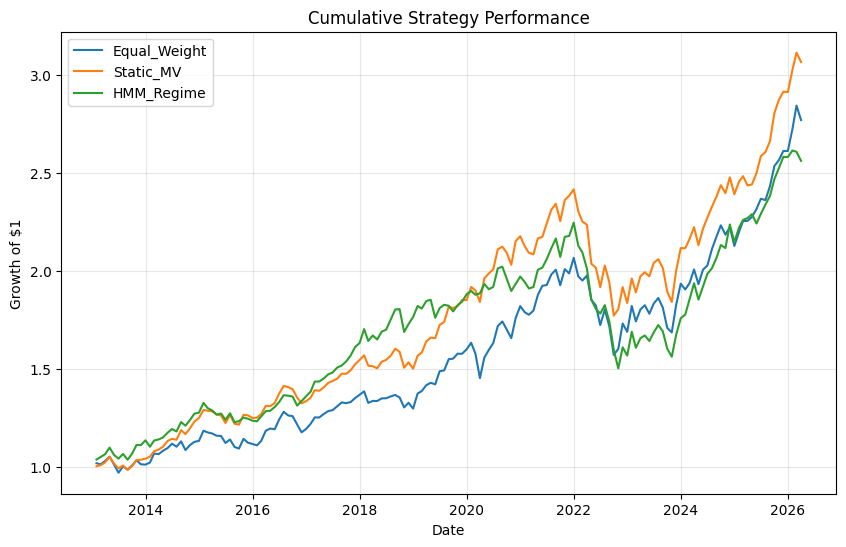

In [54]:
plt.figure(figsize=(10,6))

for col in cumulative_returns.columns:
    plt.plot(cumulative_returns.index, cumulative_returns[col], label=col)

plt.title("Cumulative Strategy Performance")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.legend()
plt.grid(True)

plt.show()

In [55]:
# ----------------------------
# Performance statistics
# ----------------------------

def performance_stats(returns):

    ann_return = (1 + returns).prod() ** (12/len(returns)) - 1
    ann_vol = returns.std() * np.sqrt(12)
    sharpe = ann_return / ann_vol

    cumulative = (1 + returns).cumprod()
    drawdown = cumulative / cumulative.cummax() - 1
    max_dd = drawdown.min()

    return pd.Series({
        "Annual Return": ann_return,
        "Annual Volatility": ann_vol,
        "Sharpe Ratio": sharpe,
        "Max Drawdown": max_dd
    })

performance_table = strategy_returns.apply(performance_stats)

display(performance_table.T)

,Annual Return,Annual Volatility,Sharpe Ratio,Max Drawdown
Equal_Weight,0.079863,0.104572,0.763708,-0.239812
Static_MV,0.088173,0.098777,0.892645,-0.266611
HMM_Regime,0.073519,0.098581,0.745772,-0.331079
